In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import numpy as np
import uproot
import awkward as ak
import matplotlib.pyplot as plt
from lightning_module import *
from plotting_utils import *
from data_utils import *

In [23]:
# Make data module
d_module = LOfData(
    mc_file='/global/cfs/cdirs/m3246/ZjetOmnifold/data/slimmed_files/WithTracks_ZjetOmnifold_May19_MGPy8FxFxRew_syst_test.root',
    data_file='/global/cfs/cdirs/m3246/ZjetOmnifold/data/slimmed_files/WithTracks_ZjetOmnifold_Aug5_PseudoDataSRew_Dec15.root',
    muon_only=False,
    batch_size=256,
    dataloader_workers=1,
    testing=True
)

Loading data...
We have a fracion 0.8091369462673238 of good events in mc
We have a fracion 1.0 of good events in pseudodata
Warning! Track kinematics shape does not match muon kinematics shape!
All done with data loading!
We have 382352 MC events and 235917 pseudo data events
We have 618269 events in total


In [24]:
# Load in model predictions and derive weights
preds = np.load('./checkpoints/test-of-project/kjj43f1q/e14_test.npy')
print(preds.shape)
probs = 1 / (1 + np.exp(-preds))
weights = probs / (1 - probs)
labels = d_module.plot_dataset[:][1].numpy().flatten()
start_weights = d_module.plot_dataset[:][2].numpy().flatten()
# end_weights = mc_weights.flatten() * weights[labels == 0]

(618269,)


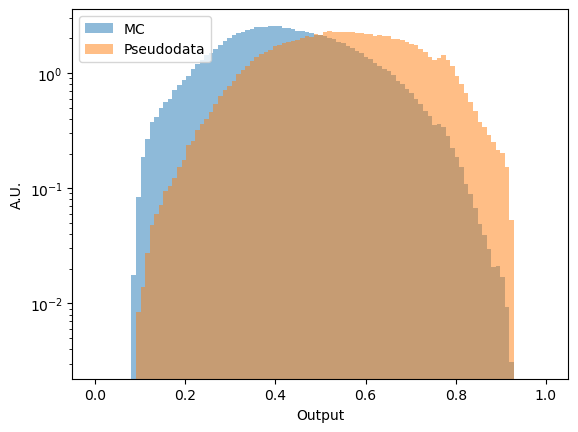

In [26]:
# Plot the output distribution
bins = np.linspace(0, 1.0, 100)
plt.hist(probs[labels == 0], bins=bins, density=True, alpha=0.5, label='MC')
plt.hist(probs[labels == 1], bins=bins, density=True, alpha=0.5, label='Pseudodata')
plt.yscale('log')
plt.xlabel('Output')
plt.ylabel('A.U.')
plt.legend()
plt.show()

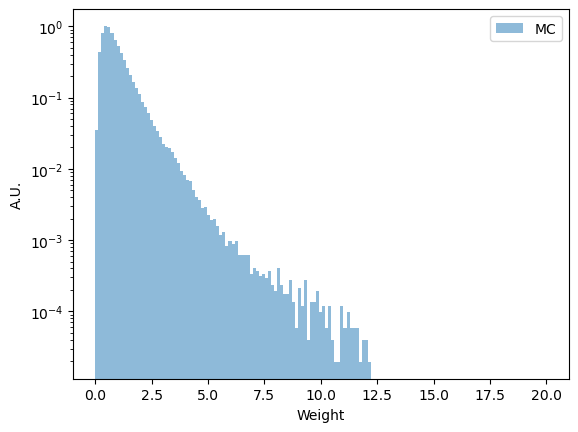

In [31]:
# Plot the weight distribution
bins = np.linspace(0, 20, 150)
plt.hist(weights[labels == 0], bins=bins, density=True, alpha=0.5, label='MC')
# plt.hist(weights[labels == 1], bins=bins, density=True, alpha=0.5, label='Pseudodata')
plt.yscale('log')
plt.xlabel('Weight')
plt.ylabel('A.U.')
plt.legend()
plt.show()

In [34]:
print(labels.shape)
print(weights.shape)

(618269,)
(618269,)


/global/u2/k/kgreif/zjets/of_transformer/plotting_utils.py:315: RuntimeWarning: divide by zero encountered in divide
  axr.plot(bins[:-1], n_mc / n_pd, color='#1f77b4', drawstyle='steps-post')
/global/u2/k/kgreif/zjets/of_transformer/plotting_utils.py:315: RuntimeWarning: invalid value encountered in divide
  axr.plot(bins[:-1], n_mc / n_pd, color='#1f77b4', drawstyle='steps-post')
/global/u2/k/kgreif/zjets/of_transformer/plotting_utils.py:316: RuntimeWarning: divide by zero encountered in divide
  axr.plot(bins[:-1], n_rw / n_pd, color='k', drawstyle='steps-post')
/global/u2/k/kgreif/zjets/of_transformer/plotting_utils.py:316: RuntimeWarning: invalid value encountered in divide
  axr.plot(bins[:-1], n_rw / n_pd, color='k', drawstyle='steps-post')


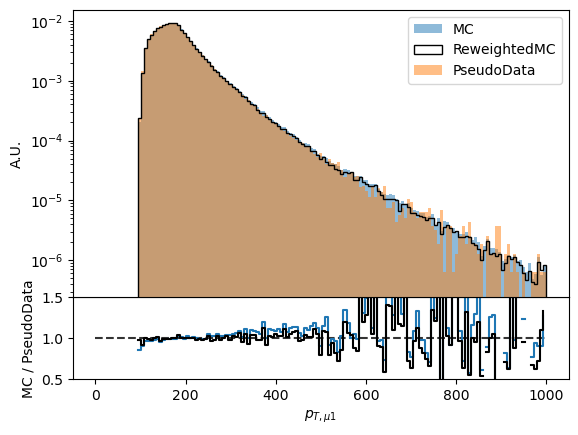

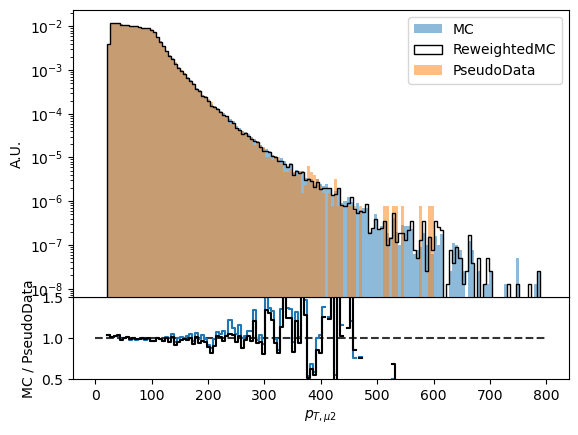

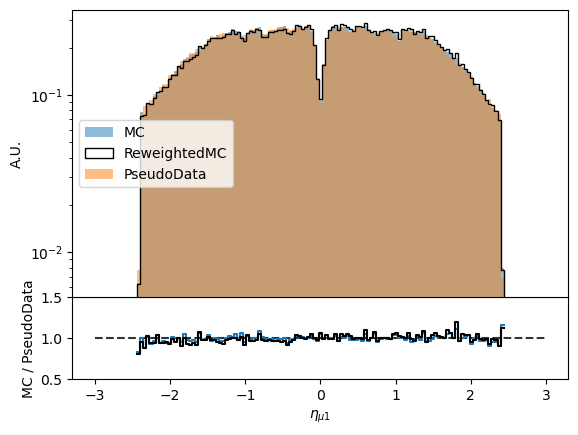

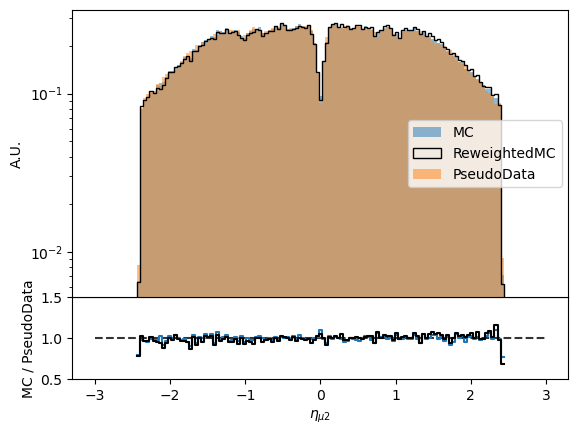

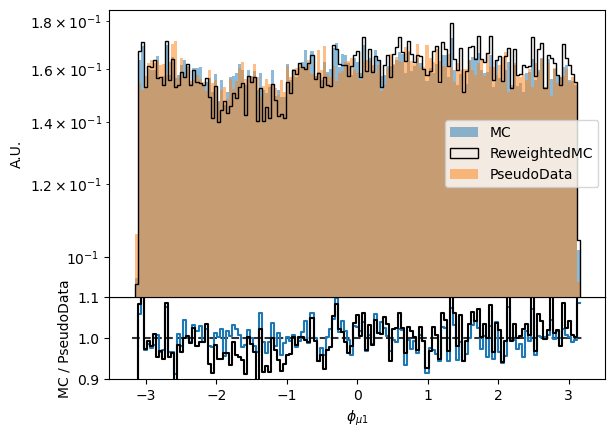

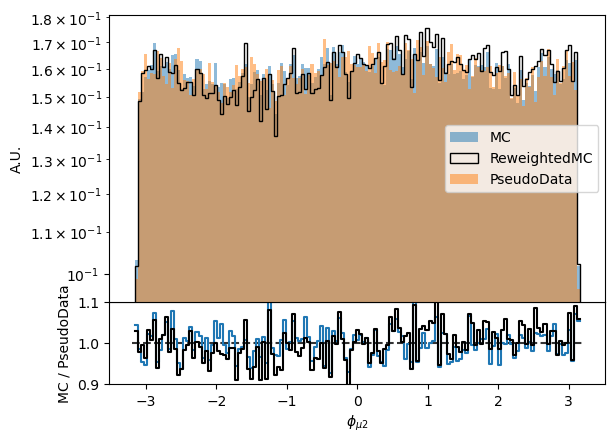

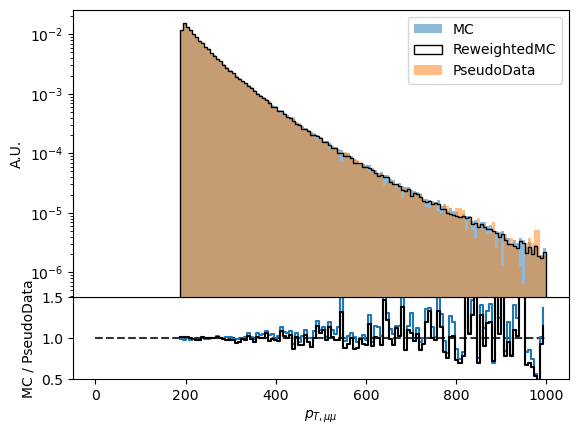

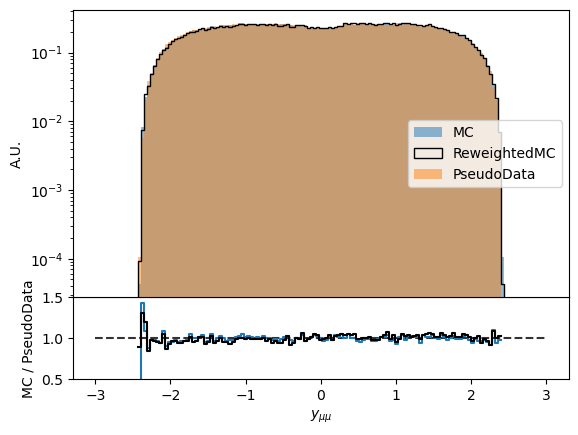

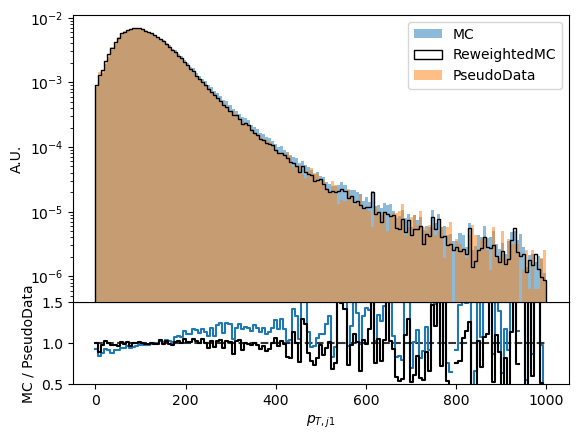

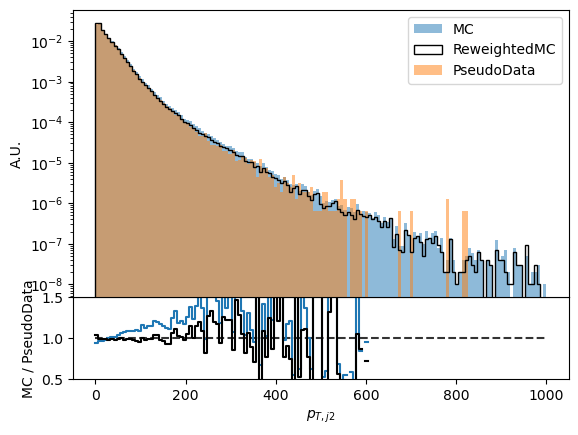

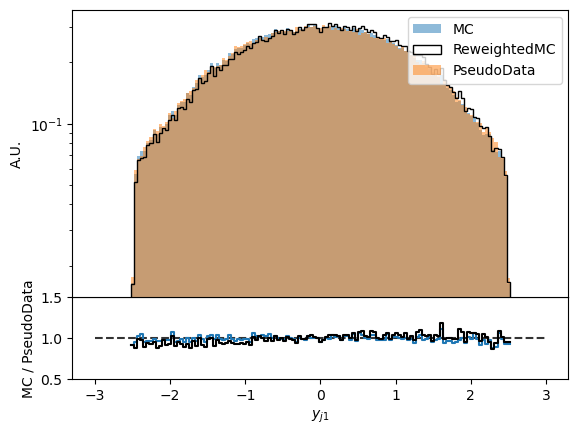

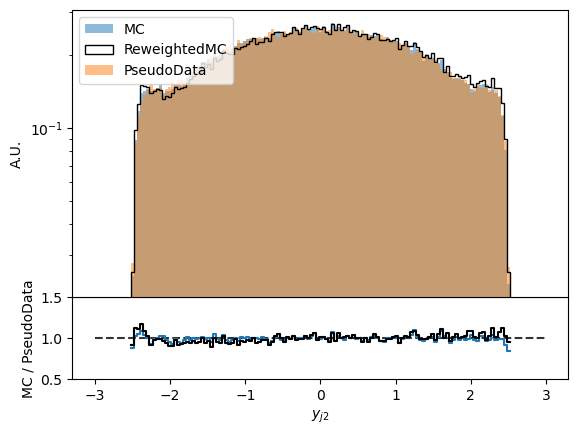

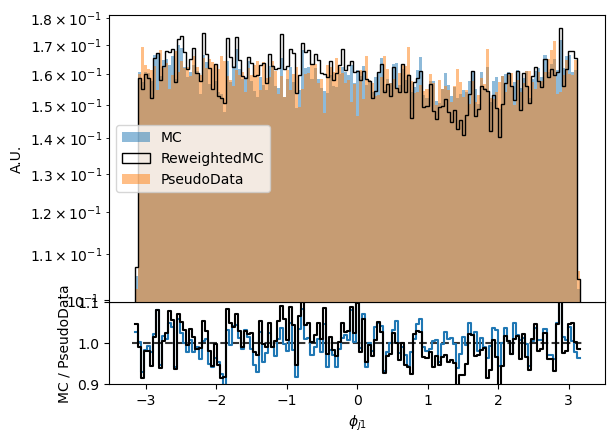

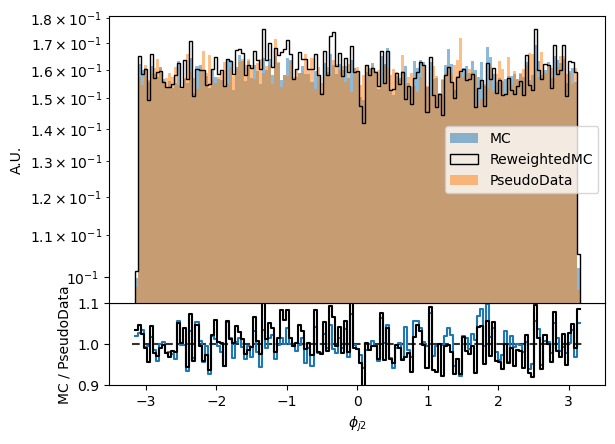

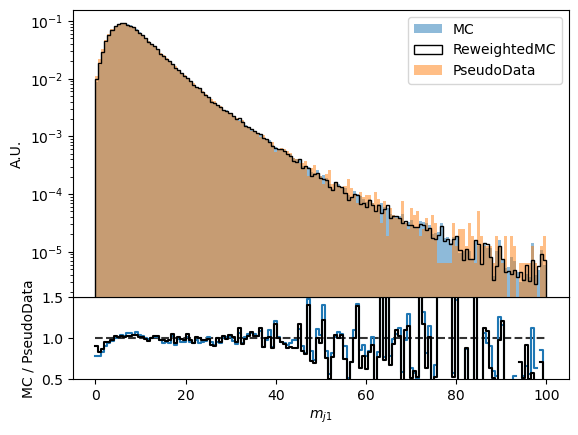

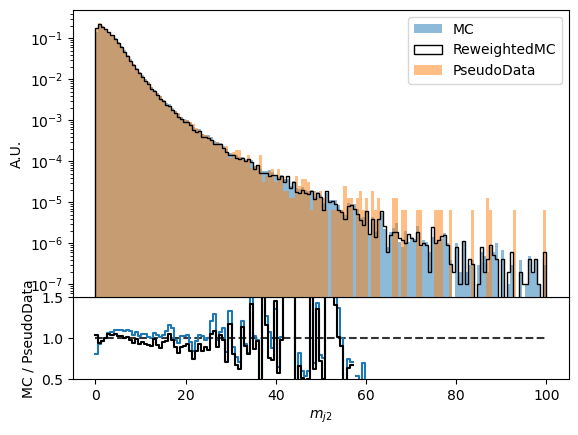

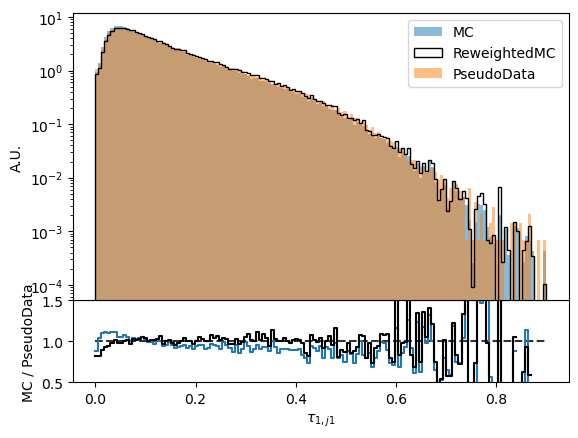

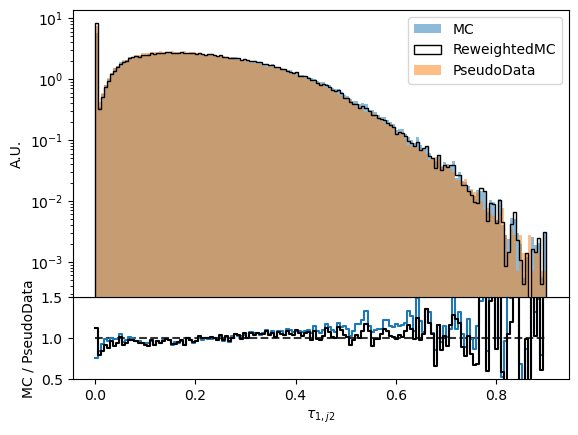

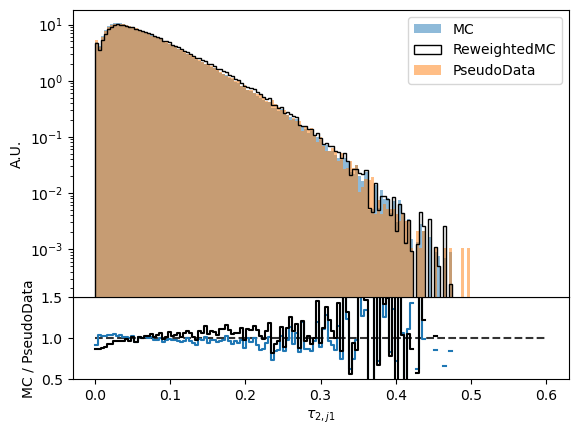

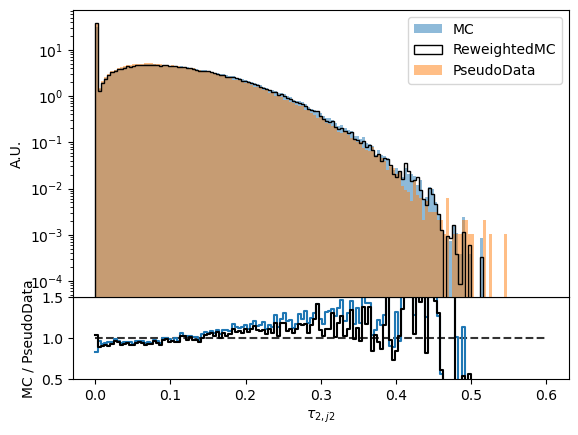

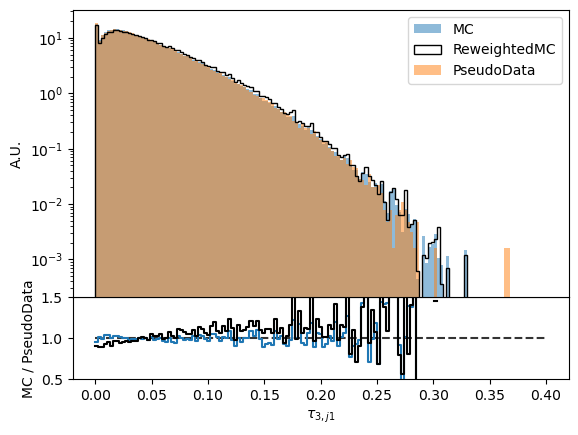

IndexError: index 21 is out of bounds for axis 1 with size 21

In [40]:
# Call plotting function
from plotting_utils import make_logged_plots
outdict = make_logged_plots(d_module.plot_dataset, preds, display=True)

In [16]:
# Plot track jet kinematics
pt_trackj1_mc = ak.to_numpy(tree_mc['pT_trackj1'].array())[pass190_mc == 1]
pt_trackj1_pd = ak.to_numpy(tree_pd['pT_trackj1'].array())[pass190_pd == 1]

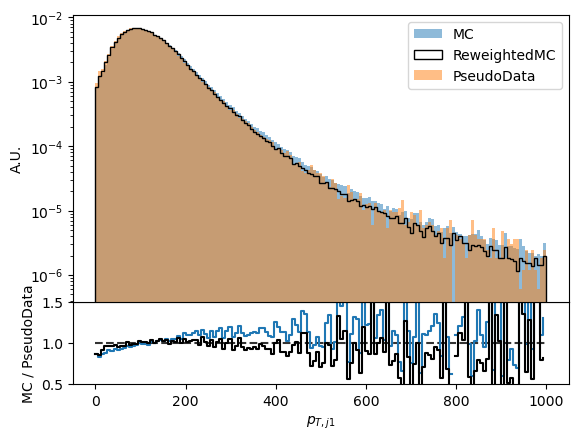

In [21]:
fig = plot_reweighting(pt_trackj1_mc, mc_weights, end_weights, pt_trackj1_pd, xlabel=r'$p_{T,j1}$', bins=np.linspace(0, 1000, 150), rlim=[0.5, 1.5])
fig.show()